In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train = pd.read_csv("/home/reidner/dev/portfolio/ds-health-insurer/data/train.csv")

print(f'train shape: {train.shape}')
print(f'train nan:\n{train.isna().sum()}')
print(f'train cols: {train.columns}')
#Region code de onde? podemos pegar zonas/estados/localizações?

train.head()

train shape: (381109, 12)
train nan:
id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64
train cols: Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='object')


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [ ]:
train.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


 ## Distribuição das variáveis categóricas

 * Cerca de 88% dos clientes são Response=0.
 * Avaliar métrica de um modelo por acurácia é enganoso, avaliar por AUC/ROC.

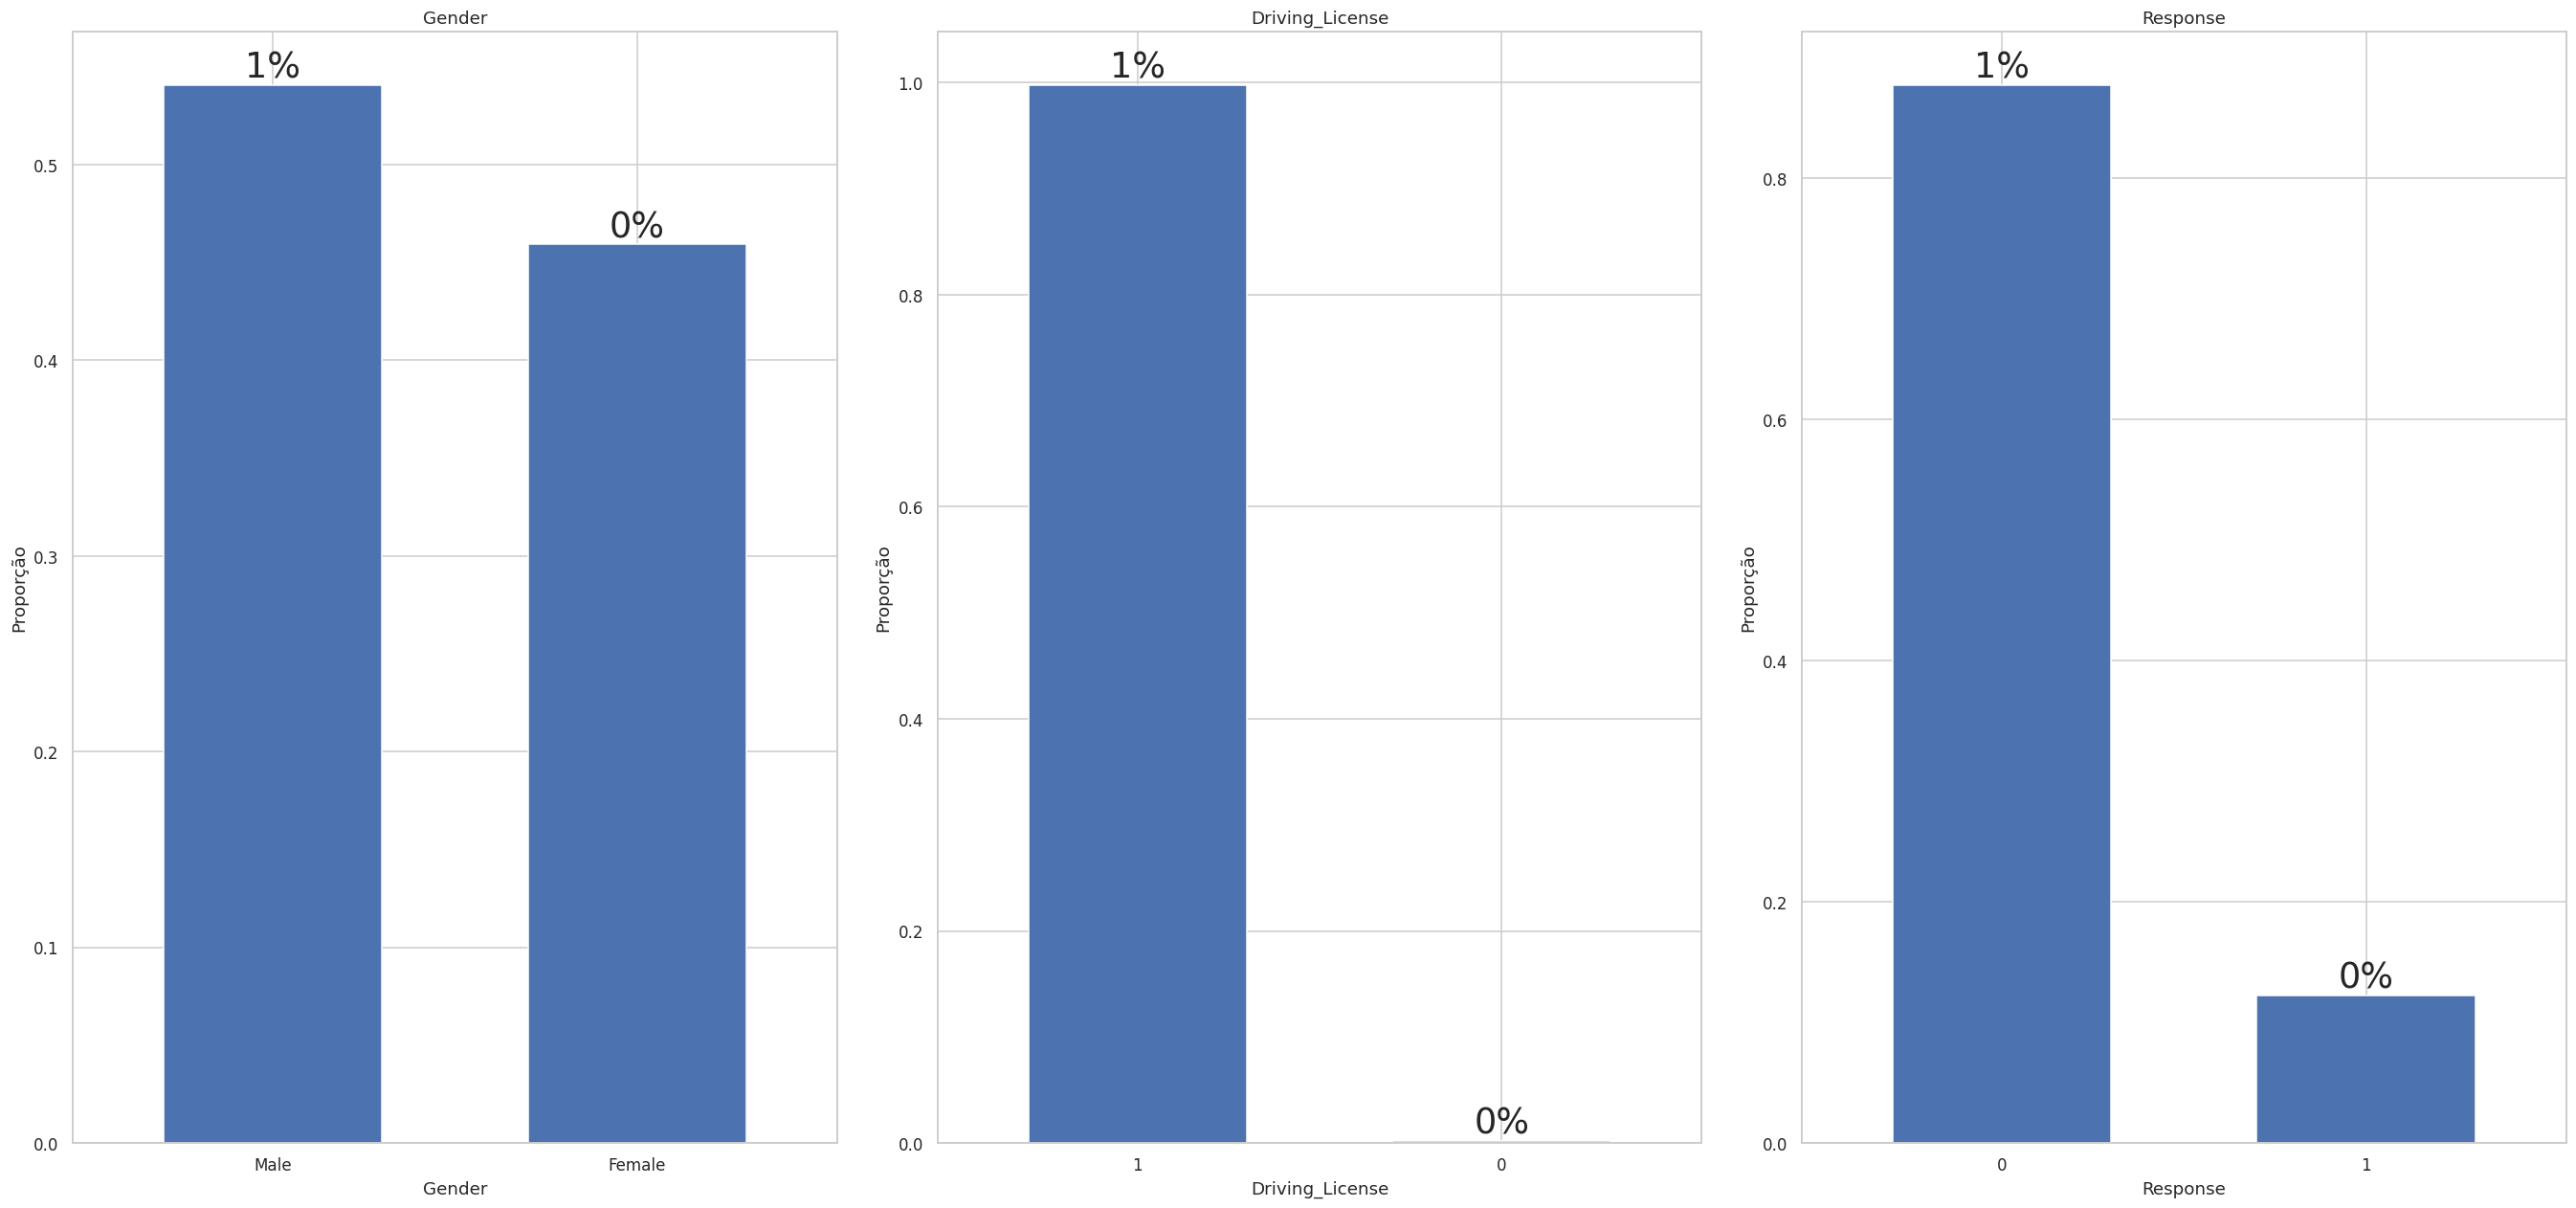

Taxa de Response=1: 0.12256336113815208


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(25, 12))
for ax, col in zip(axes, ['Gender', 'Driving_License', 'Response']):
    counts = train[col].value_counts(normalize=True)
    counts.plot(kind='bar', ax=ax, width=0.6)
    ax.set_title(col)
    ax.set_ylabel('Proporção')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.bar_label(ax.containers[0], fmt='%.0f%%')

plt.tight_layout()
plt.show()

print(f'Taxa de Response=1: {train["Response"].mean()}')

 ## Distribuição das variáveis numéricas por Response

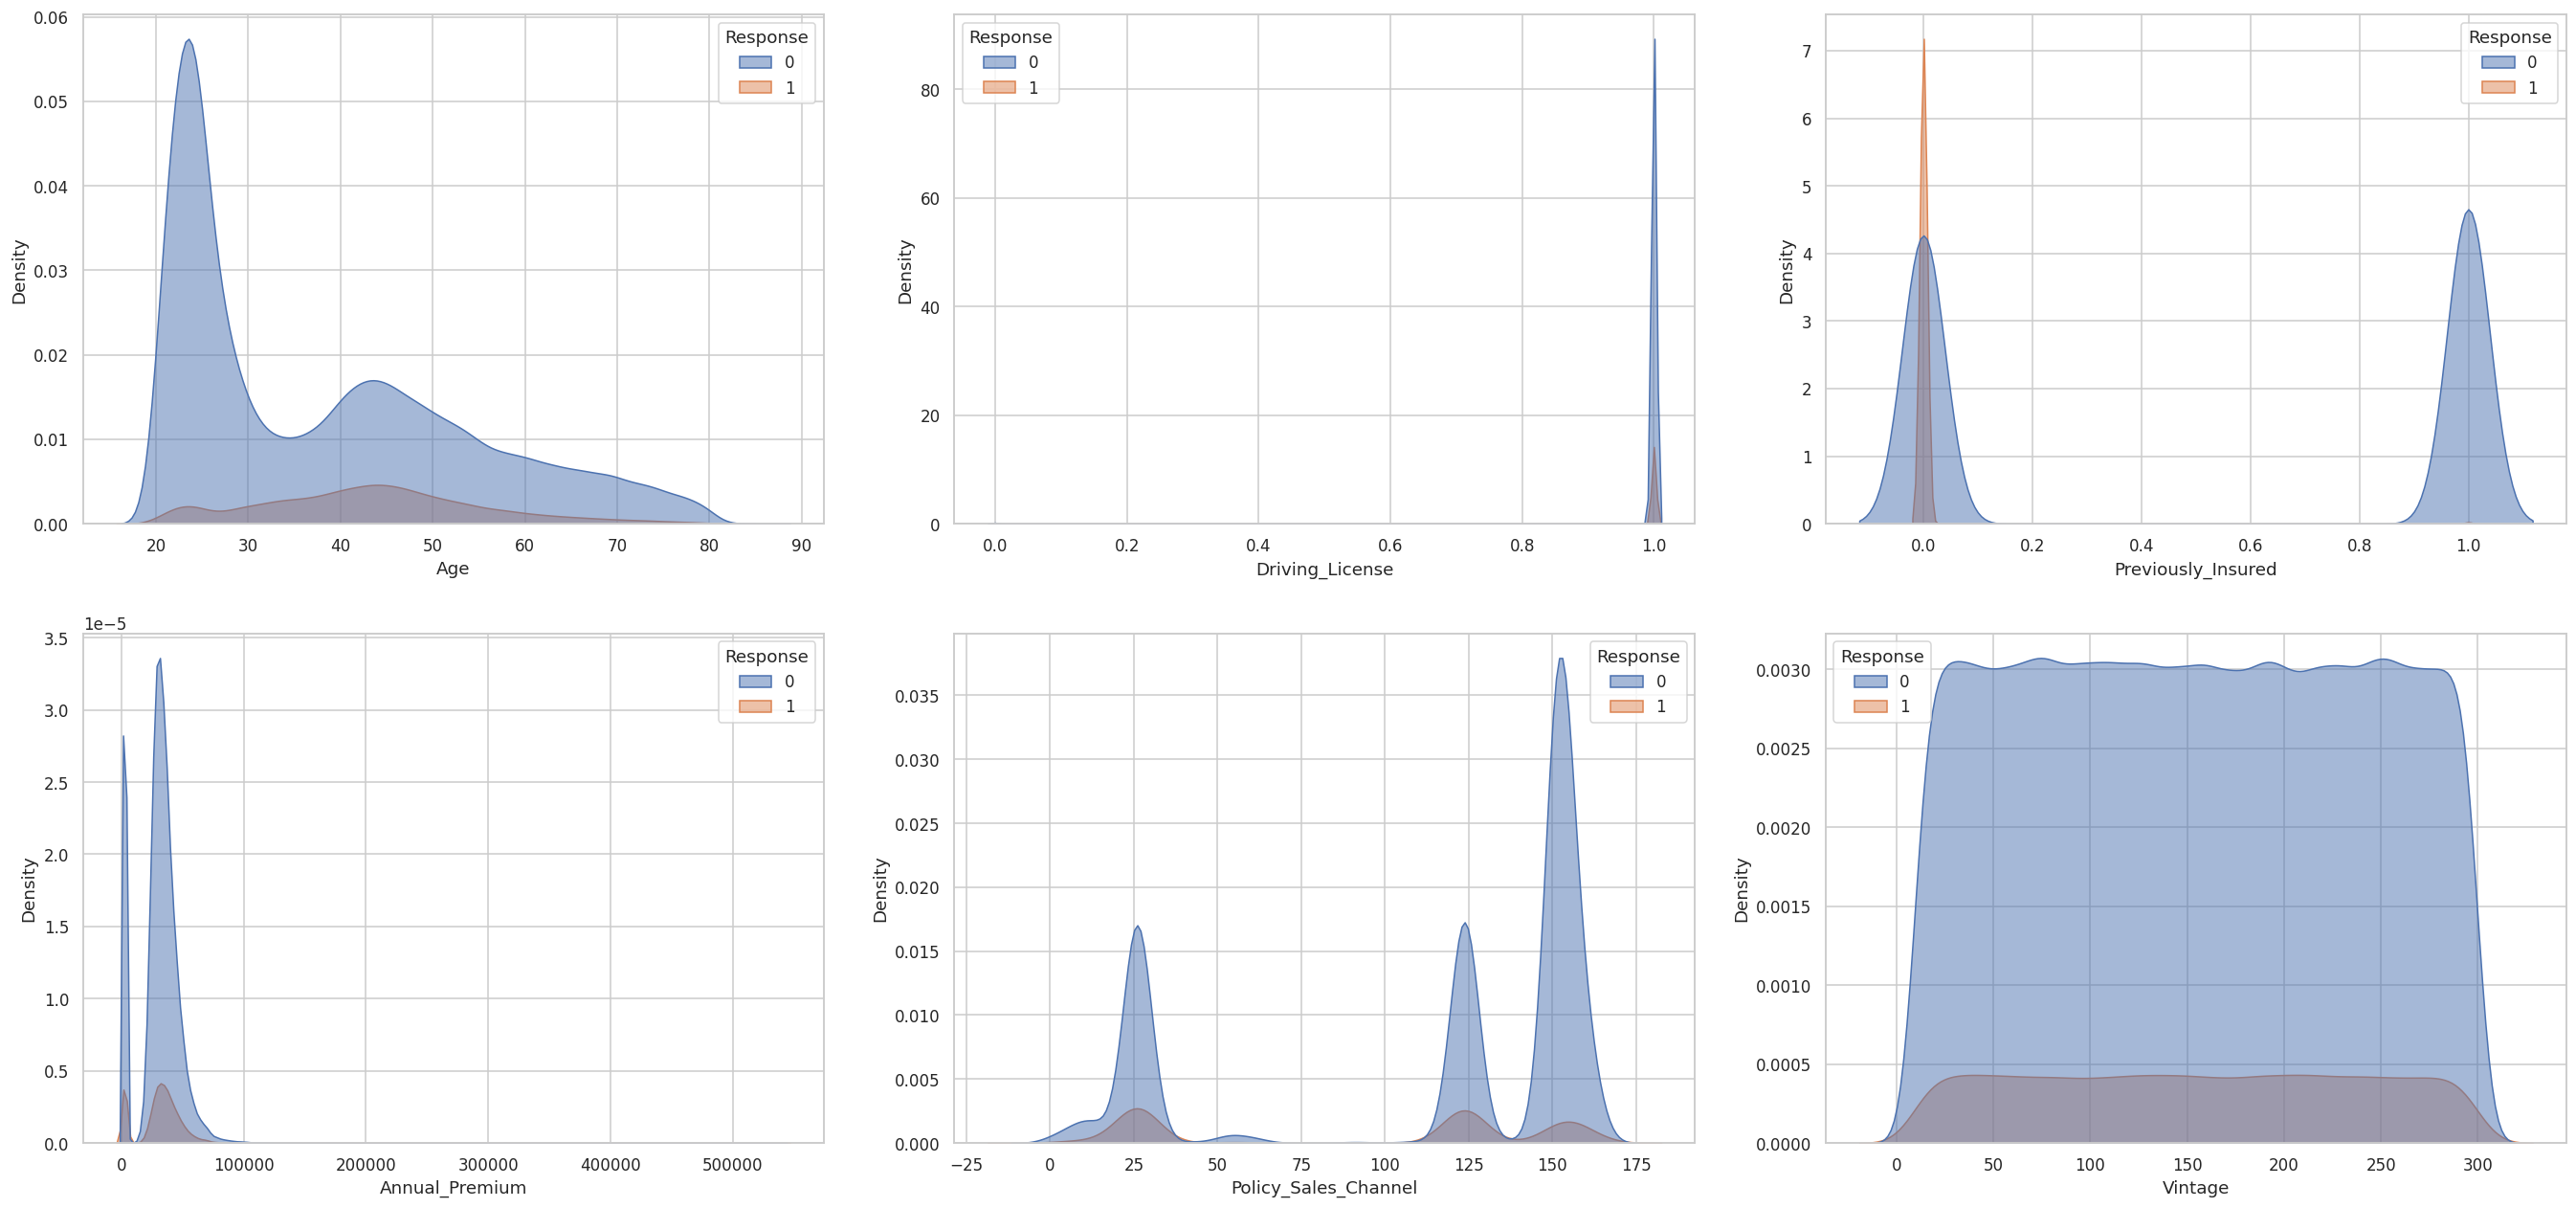

In [ ]:
exclude_cols = ["id", "Region_Code", "Response"]
cols = [c for c in train.columns if train[c].dtype != "object" and c not in exclude_cols]
ncols, nrows = 3, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 12))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, cols):
    sns.kdeplot(data=train, x=col, hue="Response", fill=True, alpha=0.5, ax=ax)

for ax in axes_flat[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

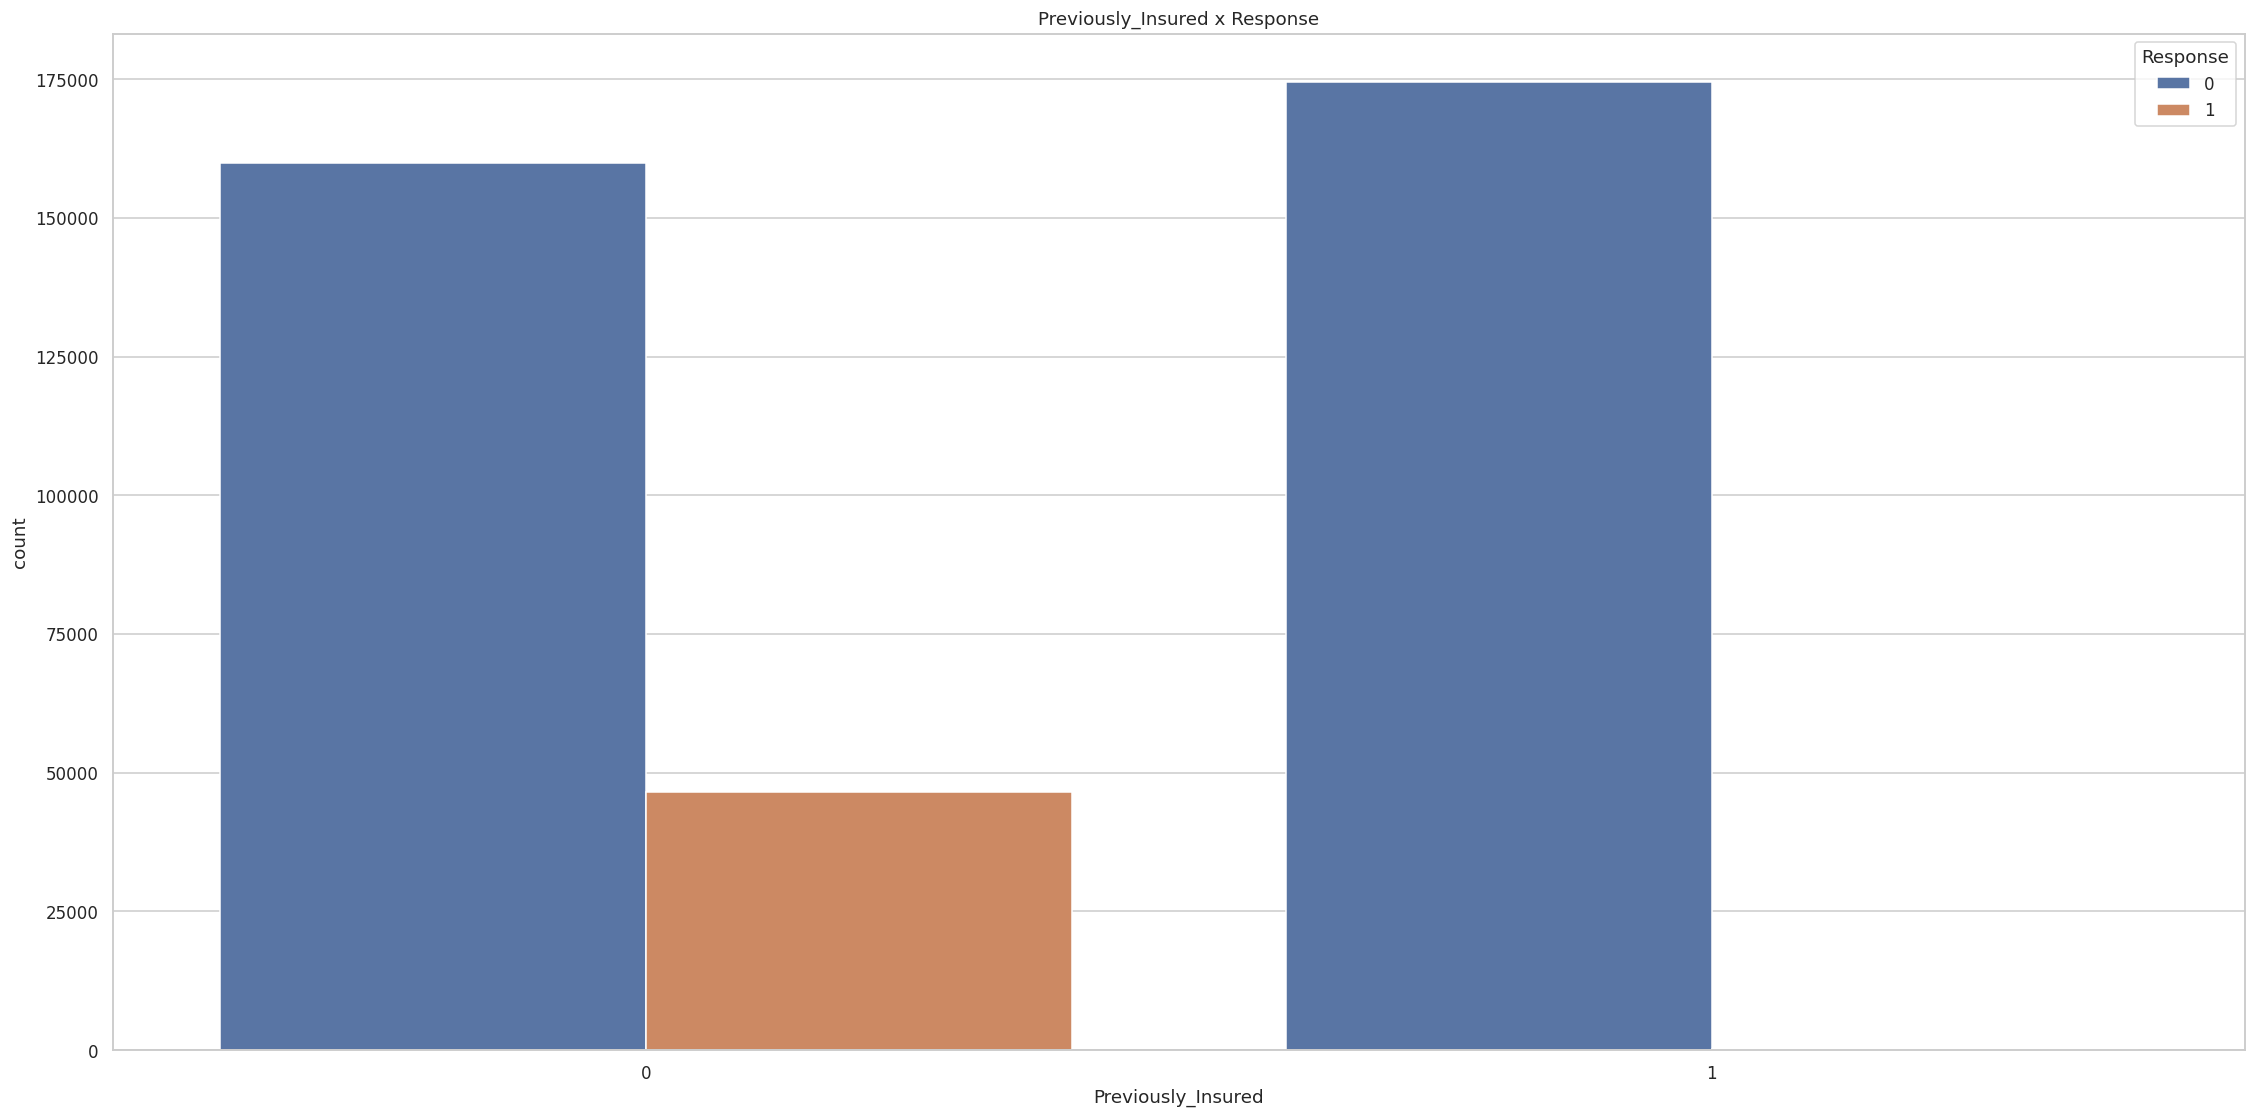

In [ ]:
sns.countplot(data=train, x="Previously_Insured", hue="Response")
plt.title("Previously_Insured x Response")
plt.xticks(rotation=0)
plt.show()

 Quem já tem seguro de veículo (1) nunca contrata novo seguro, logo, feature altamente discriminante

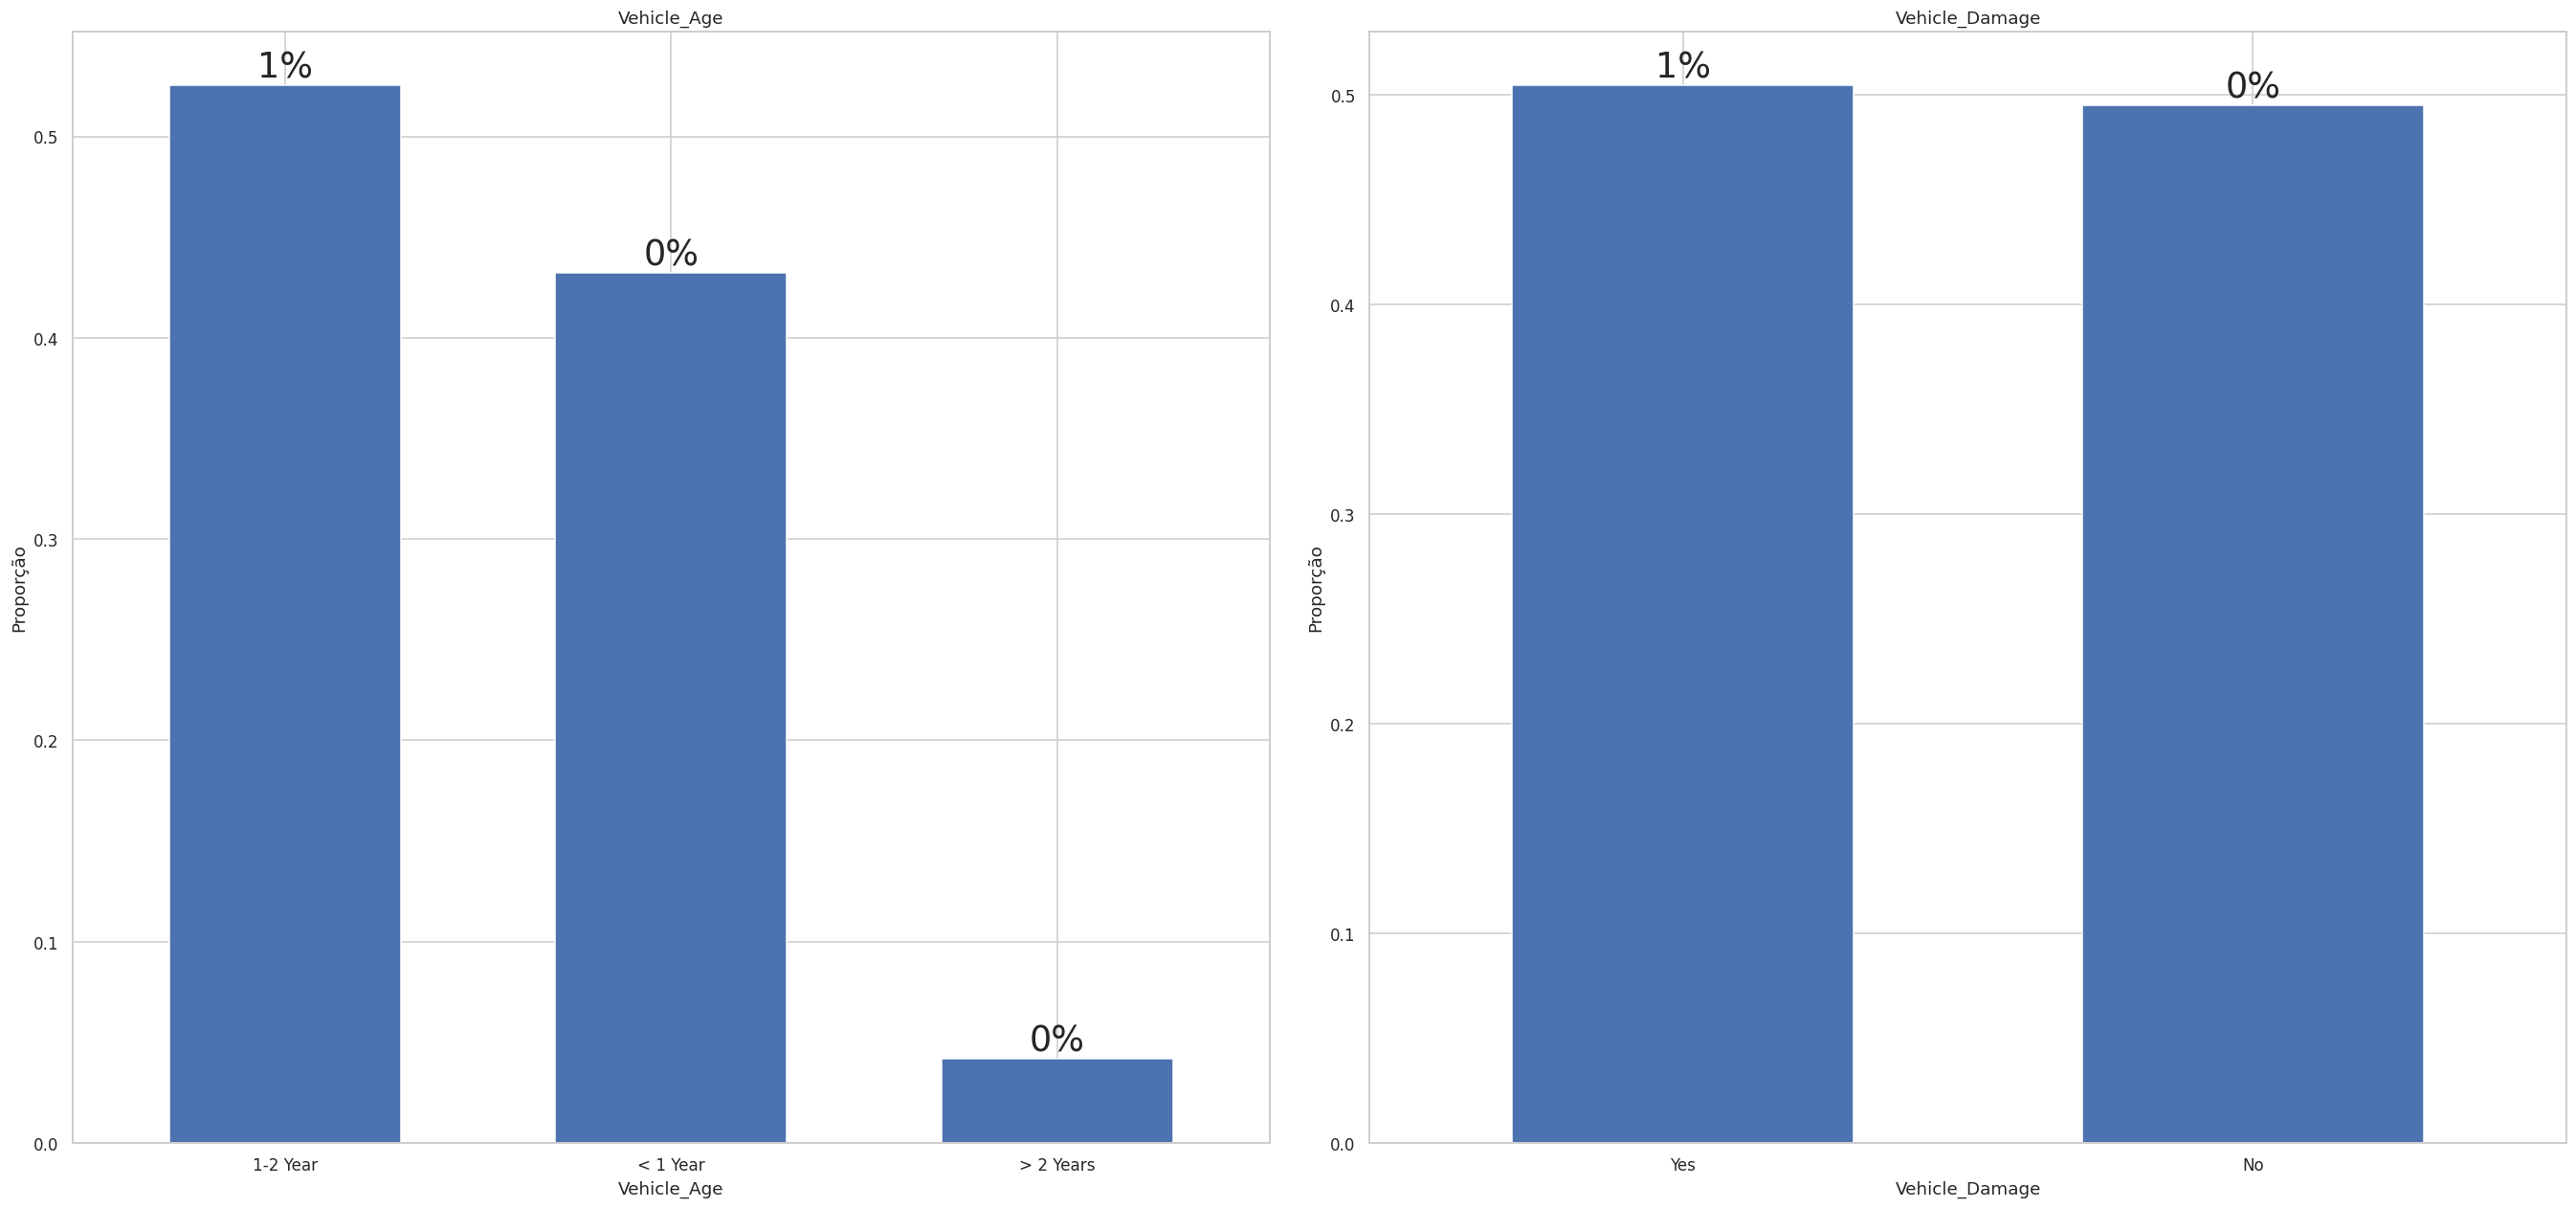

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(25, 12))
for ax, col in zip(axes, ['Vehicle_Age', 'Vehicle_Damage']):
    counts = train[col].value_counts(normalize=True)
    counts.plot(kind='bar', ax=ax, width=0.6)
    ax.set_title(col)
    ax.set_ylabel('Proporção')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.bar_label(ax.containers[0], fmt='%.0f%%')

plt.tight_layout()
plt.show()

 ## Correlação entre variáveis numéricas

 * multicolinearidade entre features pode indicar redundância de informação
 * correlação alta com Response indica poder preditivo.

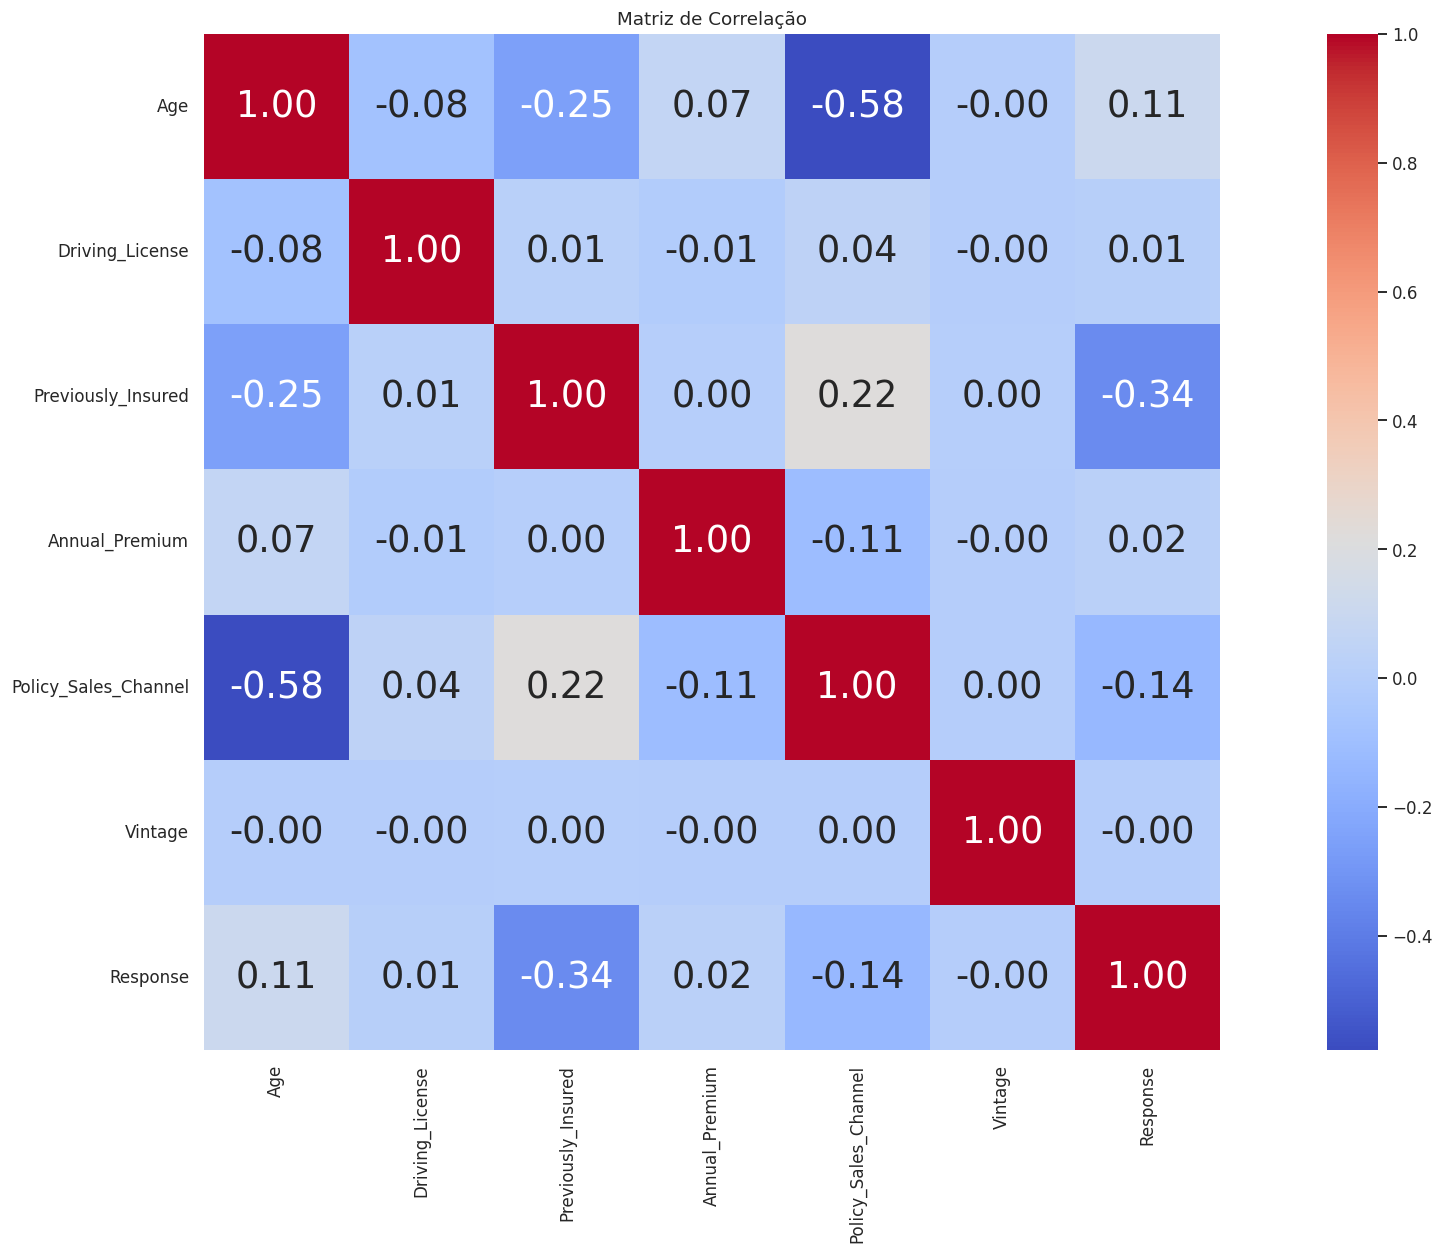

In [ ]:
num_cols = [c for c in train.columns if train[c].dtype != "object" and c not in ["id", "Region_Code"]]
plt.figure(figsize=(25, 12))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Matriz de Correlação")
plt.show()

 ## Boxplots por Response

 Compara mediana e outliers entre quem contrata novo seguro (1) e quem não contrata.

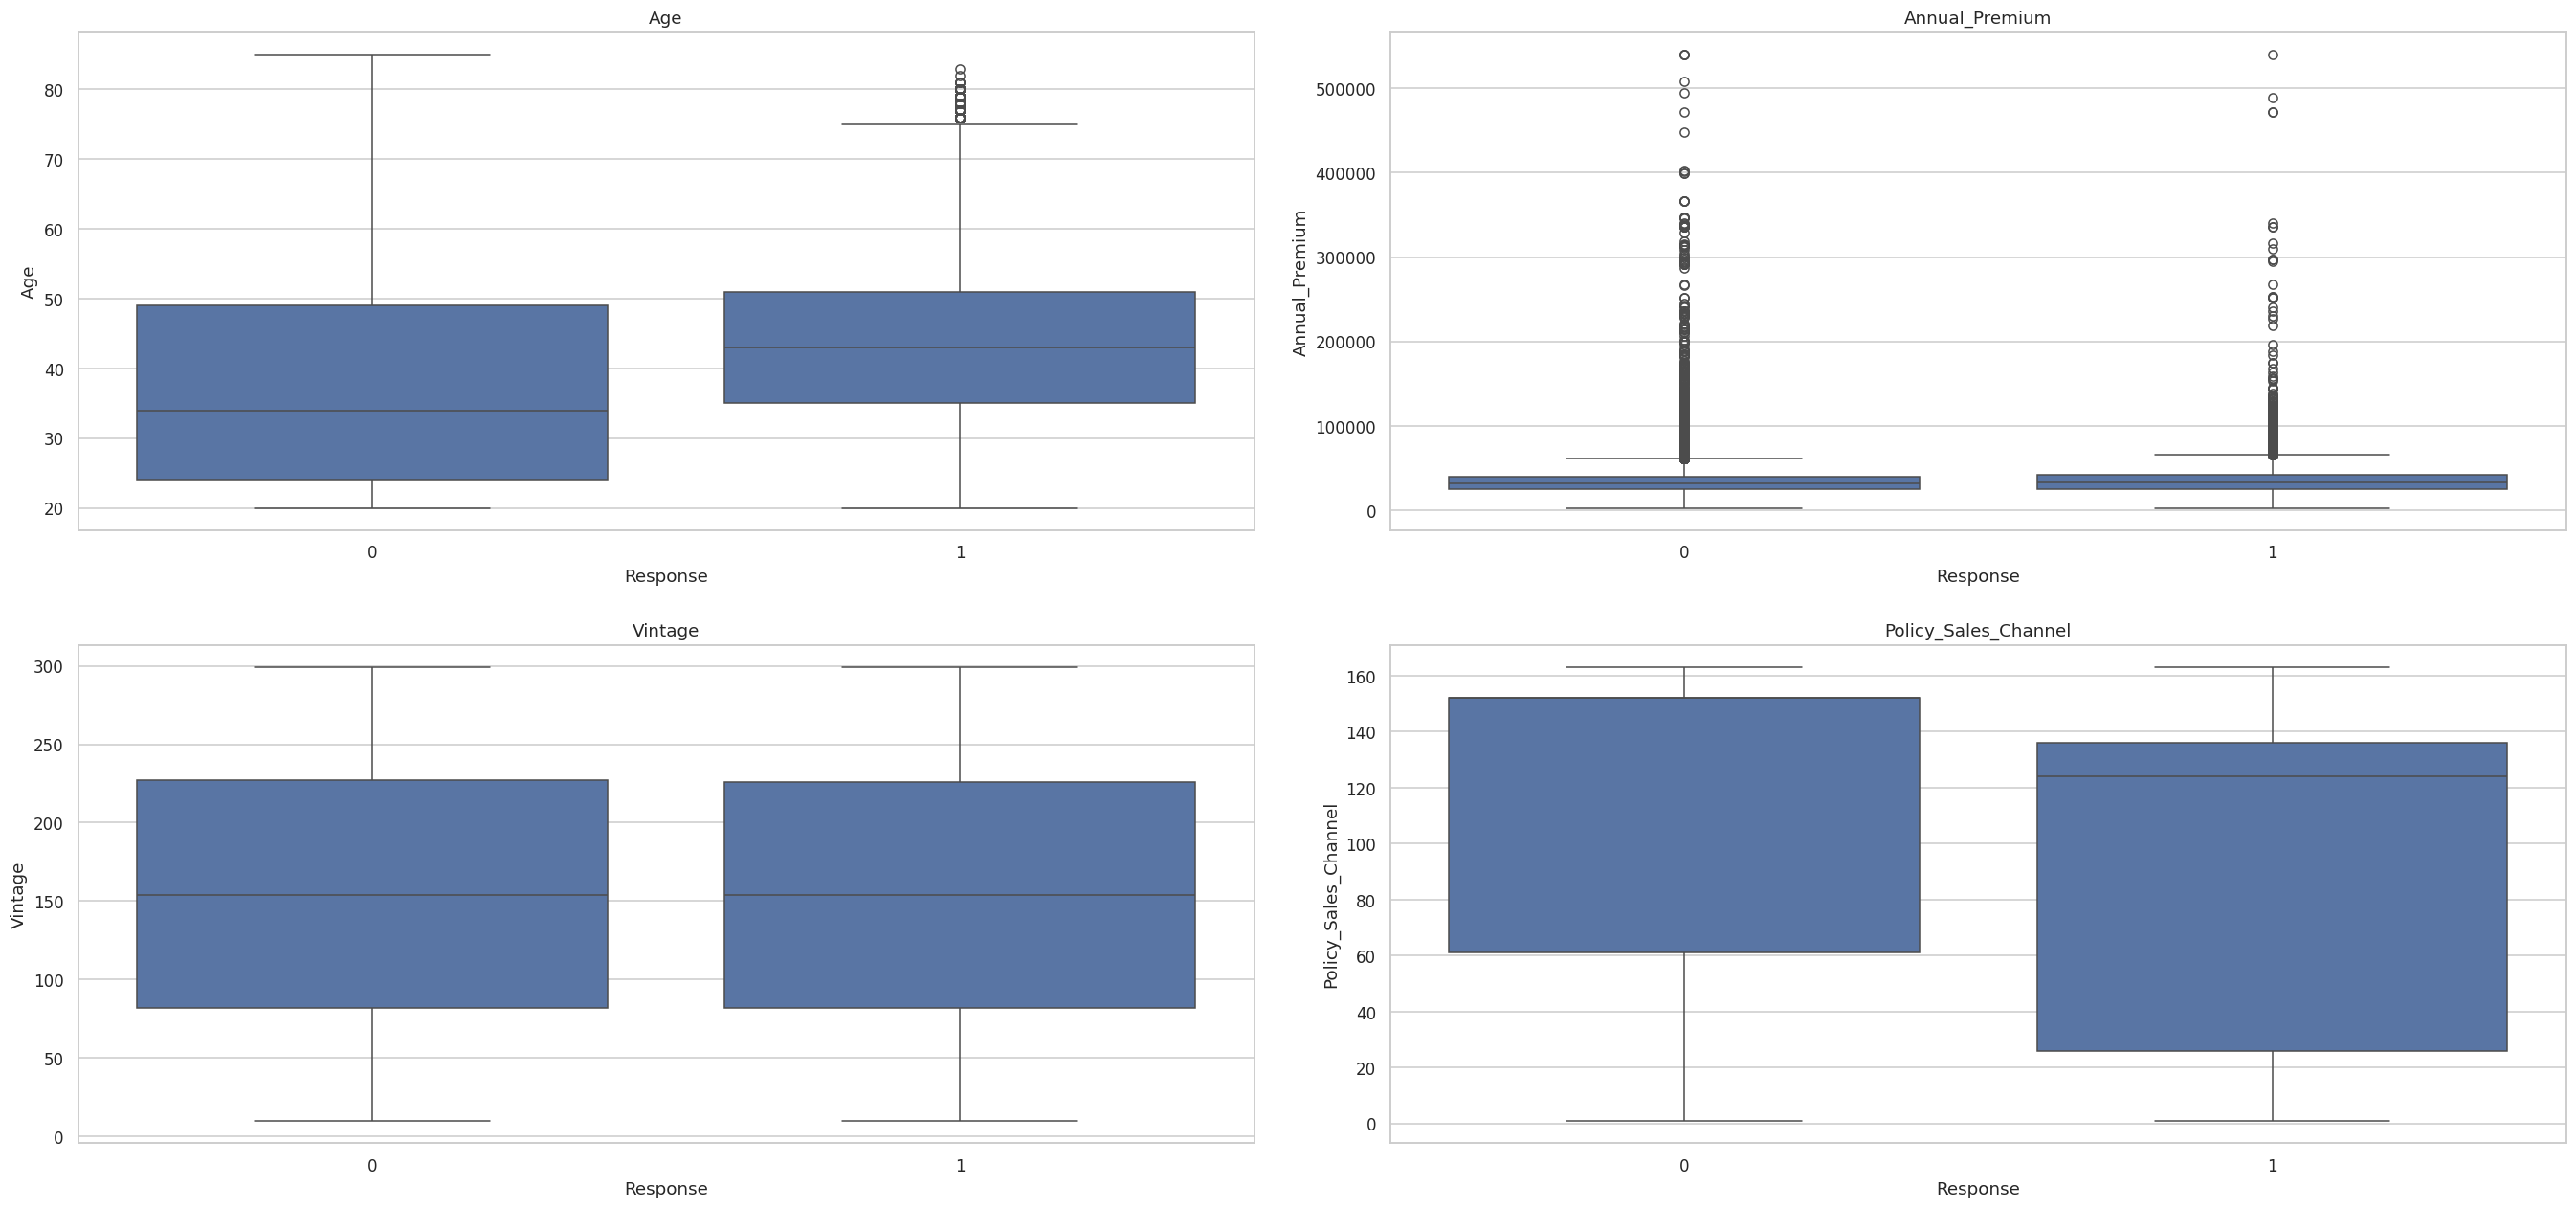

In [ ]:
box_cols = ['Age', 'Annual_Premium', 'Vintage', 'Policy_Sales_Channel']
ncols = 2
nrows = int(np.ceil(len(box_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(25, 12))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, box_cols):
    sns.boxplot(data=train, x="Response", y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

 ## Annual_Premium alto x Response

p50=31669 | n hi: 190,555 (50.0%) | resp hi: 0.134 | resp low: 0.111
p90=48431 | n hi: 38,115 (10.0%) | resp hi: 0.152 | resp low: 0.119
p99=72963 | n hi: 3,813 (1.0%) | resp hi: 0.147 | resp low: 0.122


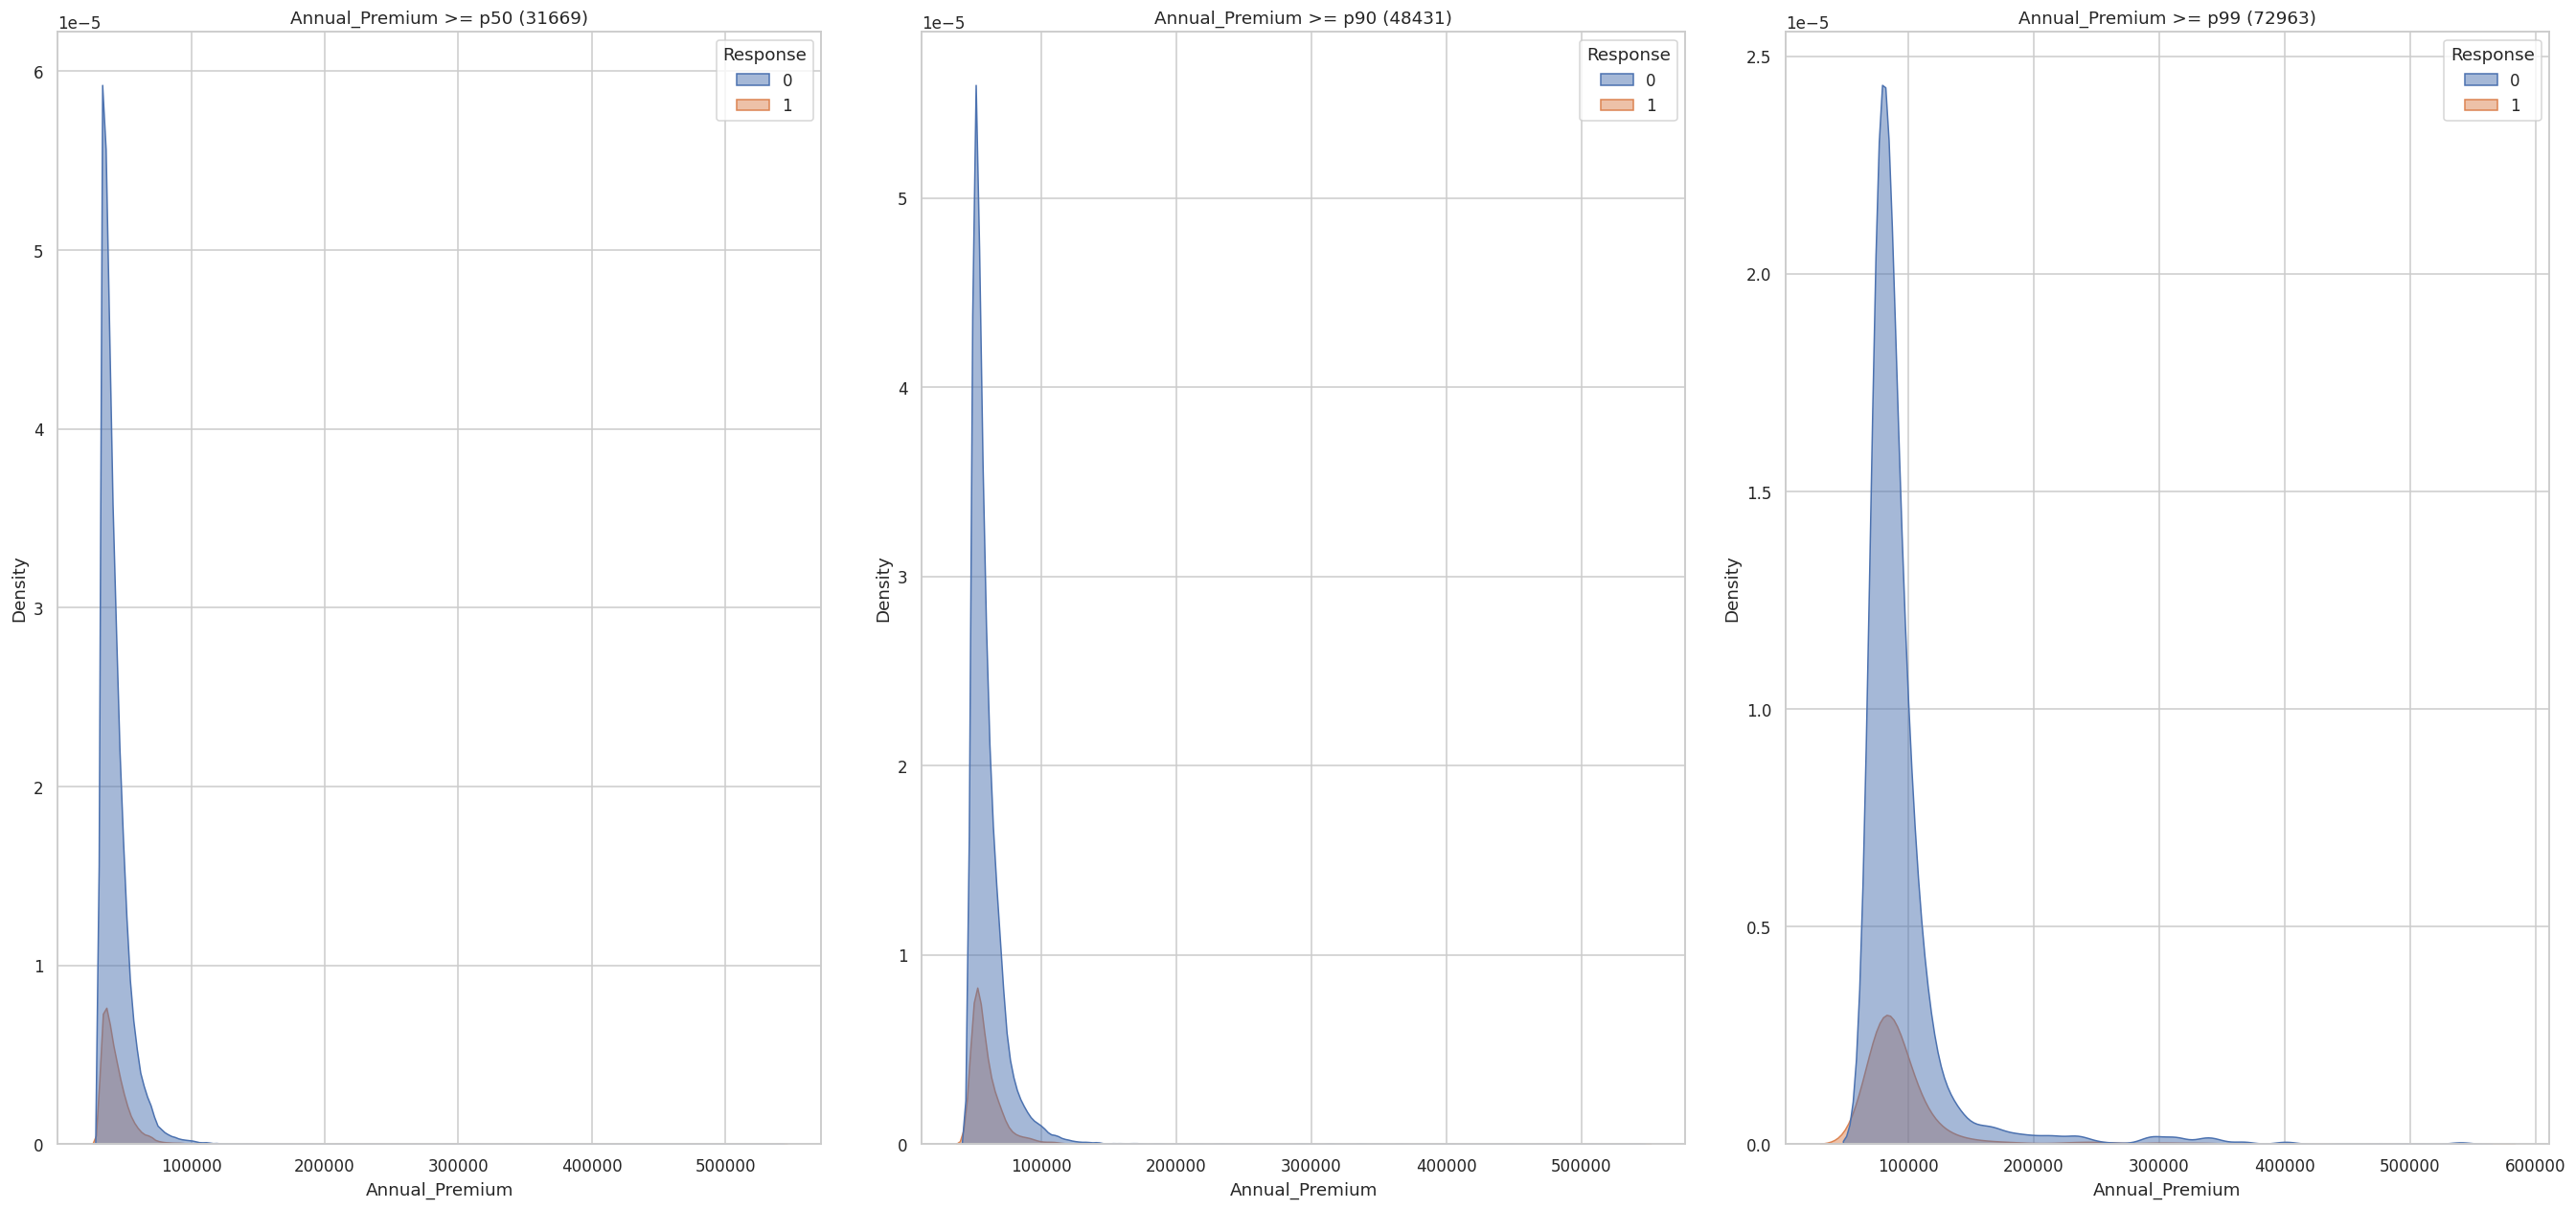

In [ ]:
for q in [0.5, 0.90, 0.99]:
    cutoff = train['Annual_Premium'].quantile(q)
    hi = train[train['Annual_Premium'] >= cutoff]
    low = train[train['Annual_Premium'] < cutoff]
    print(f'p{int(q*100)}={cutoff:.0f} | n hi: {len(hi):,} ({len(hi)/len(train):.1%}) | resp hi: {hi.Response.mean():.3f} | resp low: {low.Response.mean():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(25, 12))
for ax, q in zip(axes, [0.5, 0.90, 0.99]):
    cutoff = train['Annual_Premium'].quantile(q)
    hi = train[train['Annual_Premium'] >= cutoff]
    sns.kdeplot(data=hi, x='Annual_Premium', hue='Response', fill=True, alpha=0.5, ax=ax)
    ax.set_title(f'Annual_Premium >= p{int(q*100)} ({cutoff:.0f})')
plt.tight_layout()
plt.show()

 ## Possíveis novas variáveis

 - Vehicle_Damage vira binária
 - Vehicle_Age já é ordenada: virar ordinal (0, 1, 2) em vez de 3 dummies
 - Age em faixas (ex.: 5 bins)
 - region_freq: frequência normalizada do Region_Code  Precisa ser calculada só em train
 - channel_freq: o mesmo para Policy_Sales_Channel (155 níveis)
 Dados geográficos externos ficaram de fora: o Region_Code é anonimizado